# 🛠 Análise labels - Dataset Wash

## 1️⃣ Setup e Configuração

In [35]:
import sys
from loguru import logger
import pandas as pd

from src.api.schemas.experiment import ExperimentRequest

logger.remove()
logger.add(
    sys.stdout,
    format="<green>{time:HH:mm:ss}</green> | <level>{level: <8}</level> | <level>{message}</level>",
    level="INFO"
)

logger.success("✓ Setup completo")

16:17:17 | SUCCESS  | ✓ Setup completo


In [36]:
import json
from pathlib import Path

experiment = "experiment_3_models"

# Load JSON from file
config_path = Path(f"../experiments/{experiment}.json")

with open(config_path, "r") as f:
    config_dict = json.load(f)

# Instantiate Pydantic model
EXPERIMENT_CONFIG = ExperimentRequest(**config_dict)

### - Configurações de dataset

In [37]:
dataset_cfg = EXPERIMENT_CONFIG.dataset_config

dataset_split = dataset_cfg.split
combine_splits = dataset_cfg.combine_splits
sample_size = dataset_cfg.sample_size
random_state = dataset_cfg.random_state

### - Configurações de cache

In [38]:
cache_cfg = EXPERIMENT_CONFIG.cache

cache_enabled = cache_cfg.enabled
cache_dir = cache_cfg.dir

## 2️⃣ Carregar Dataset do HuggingFace

In [39]:
from src.utils.data_loader import load_hf_dataset_as_dataframe, list_available_datasets

logger.info("Datasets disponíveis:")
for dataset in list_available_datasets():
    logger.info(f"  - {dataset}")

16:17:17 | INFO     | Datasets disponíveis:
16:17:17 | INFO     |   - agnews
16:17:17 | INFO     |   - mpqa
16:17:17 | INFO     |   - webkb
16:17:17 | INFO     |   - ohsumed
16:17:17 | INFO     |   - acm
16:17:17 | INFO     |   - yelp_2013
16:17:17 | INFO     |   - dblp
16:17:17 | INFO     |   - books
16:17:17 | INFO     |   - reut90
16:17:17 | INFO     |   - wos11967
16:17:17 | INFO     |   - twitter
16:17:17 | INFO     |   - trec
16:17:17 | INFO     |   - wos5736
16:17:17 | INFO     |   - sst1
16:17:17 | INFO     |   - pang_movie
16:17:17 | INFO     |   - movie_review
16:17:17 | INFO     |   - vader_movie
16:17:17 | INFO     |   - subj
16:17:17 | INFO     |   - sst2
16:17:17 | INFO     |   - yelp_reviews
16:17:17 | INFO     |   - 20ng
16:17:17 | INFO     |   - medline


In [40]:
# Carregar dataset
dataset_name = "movie_review"  # Ajuste conforme necessário

In [41]:
df, categories = load_hf_dataset_as_dataframe(
    dataset_name=dataset_name,
    cache_dir=cache_dir,
    dataset_global_config=dataset_cfg
)

df = pd.DataFrame(df)

16:17:17 | INFO     | Carregando dataset: movie_review
16:17:23 | INFO     | Split 'train': 95958 exemplos
16:17:23 | INFO     | Categorias extraídas automaticamente: [0, 1]
16:17:23 | INFO     | Amostra reduzida para 5000 exemplos (seed=42)
16:17:23 | INFO     | Coluna de texto: text
16:17:23 | INFO     | Ground truth carregado da coluna 'label'
16:17:23 | INFO     | DataFrame criado com 5000 linhas


In [42]:
df

,text,label,label_description
0,an escapist confection that's pure entertainme...,1,positive sentiment
1,the impact of the armenian genocide is diluted...,0,negative sentiment
2,"off the hook is overlong and not well-acted , ...",0,negative sentiment
3,ends up being mostly about ravishing costumes ...,0,negative sentiment
4,it offers a glimpse of the solomonic decision ...,1,positive sentiment
...,...,...,...
4995,writer-director walter hill and co-writer davi...,0,negative sentiment
4996,the very definition of what critics have come ...,0,negative sentiment
4997,though it was made with careful attention to d...,0,negative sentiment
4998,while the story is better-focused than the inc...,0,negative sentiment


## 3) Validando labels

In [43]:
df[df["label"] == 1][["text", "label", "label_description"]].sample(10)

,text,label,label_description
2516,"streamlined to a tight , brisk 85-minute screw...",1,positive sentiment
2909,jarecki and gibney do find enough material to ...,1,positive sentiment
3914,"this is a movie full of grace and , ultimately...",1,positive sentiment
1687,what's surprising about full frontal is that d...,1,positive sentiment
2397,beneath clouds is a succinct low-budget film w...,1,positive sentiment
1192,"' . . . both hokey and super-cool , and defini...",1,positive sentiment
381,. . . rogers's mouth never stops shut about th...,1,positive sentiment
3322,it manages to squeeze by on angelina jolie's s...,1,positive sentiment
3665,"a slick , well-oiled machine , exquisitely pol...",1,positive sentiment
3844,"human resources was a good , straightforward t...",1,positive sentiment


## 4) Distribuição

Frequência absoluta:
label
0    2535
1    2465
Name: count, dtype: int64

Frequência relativa:
label
0    0.507
1    0.493
Name: proportion, dtype: float64


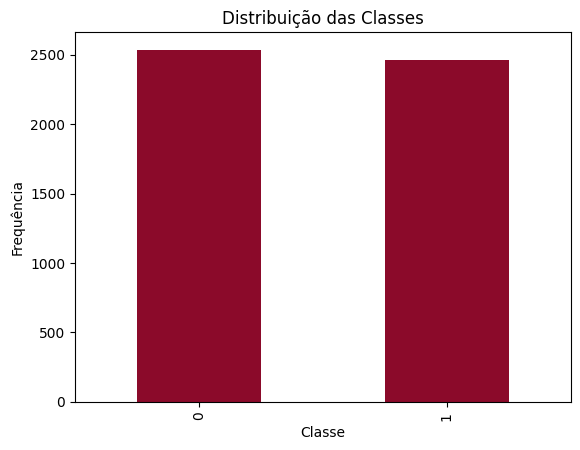

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

counts = df['label'].value_counts().sort_index()
proportions = df['label'].value_counts(normalize=True).sort_index()

print("Frequência absoluta:")
print(counts)

print("\nFrequência relativa:")
print(proportions)

counts.plot(kind='bar', color="#8B0A2A")
plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Frequência")
plt.show()

In [45]:
from scipy.stats import chisquare
import numpy as np

observed = counts.values
expected = np.ones(len(observed)) * (sum(observed) / len(observed))

chi2, p_value = chisquare(f_obs=observed, f_exp=expected)

print("Chi2:", chi2)
print("p-value:", p_value)

Chi2: 0.98
p-value: 0.3221988061625787
